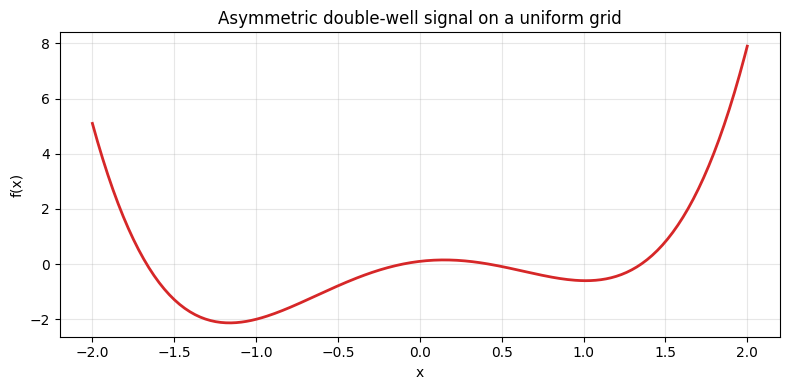

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Same asymmetric double-well function used in the reference notebook.
def double_well(x):
    return x ** 4 - 2.4 * x ** 2 + 0.7 * x + 0.1

num_points = 256  # power of two for a clean multilevel Haar decomposition
x_grid = np.linspace(-2.0, 2.0, num_points)
signal = double_well(x_grid)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(x_grid, signal, color='tab:red', linewidth=2.0)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Asymmetric double-well signal on a uniform grid')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
def haar_dwt_step(values):
    values = np.asarray(values, dtype=float)
    if values.size % 2 != 0:
        raise ValueError('Haar transform requires an even number of samples at each level.')

    even = values[0::2]
    odd = values[1::2]
    approximation = (even + odd) / np.sqrt(2.0)
    detail = (even - odd) / np.sqrt(2.0)
    return approximation, detail


def multilevel_haar_dwt(values, levels=None):
    values = np.asarray(values, dtype=float)
    max_levels = int(np.log2(values.size))
    if 2 ** max_levels != values.size:
        raise ValueError('Signal length must be a power of two for this simple implementation.')

    if levels is None:
        levels = max_levels
    if levels < 1 or levels > max_levels:
        raise ValueError(f'levels must be between 1 and {max_levels}.')

    approximations = [values]
    details = []
    current = values
    for _ in range(levels):
        current, detail = haar_dwt_step(current)
        approximations.append(current)
        details.append(detail)
    return approximations, details


def reconstruct_from_coeffs(final_approximation, details):
    current_approximation = np.asarray(final_approximation, dtype=float)
    for detail_coefficients in reversed(details):
        detail_coefficients = np.asarray(detail_coefficients, dtype=float)

        if current_approximation.shape != detail_coefficients.shape:
            raise ValueError('Approximation and detail coefficients must have the same shape at each level.')

        reconstructed_level = np.empty(detail_coefficients.size * 2, dtype=float)

        even_samples = (current_approximation + detail_coefficients) / np.sqrt(2.0)
        odd_samples = (current_approximation - detail_coefficients) / np.sqrt(2.0)

        reconstructed_level[0::2] = even_samples
        reconstructed_level[1::2] = odd_samples

        current_approximation = reconstructed_level

    return current_approximation


levels = 5
approximations, details = multilevel_haar_dwt(signal, levels=levels)
reconstructed = reconstruct_from_coeffs(approximations[-1], details)


## How many coefficients do we have at each level?

For a signal of length $N$, each Haar step splits the current approximation into:

- a new approximation block
- a detail block

The current approximation always gets cut in half at each step.

### Level 1

- $A_1$: $N/2$ coefficients
- $D_1$: $N/2$ coefficients
- total stored at level 1: $N$

For $N = 256$:

- $A_1$: 128 coefficients
- $D_1$: 128 coefficients

### Level 2

At level 2, $A_1$ is decomposed again, so it is replaced by $A_2$ and $D_2$.

- $A_2$: $N/4$ coefficients
- $D_2$: $N/4$ coefficients
- $D_1$: $N/2$ coefficients
- total stored at level 2: $N$

For $N = 256$:

- $A_2$: 64 coefficients
- $D_2$: 64 coefficients
- $D_1$: 128 coefficients

### Level 3

- $A_3$: $N/8$ coefficients
- $D_3$: $N/8$ coefficients
- $D_2$: $N/4$ coefficients
- $D_1$: $N/2$ coefficients
- total stored at level 3: $N$

For $N = 256$:

- $A_3$: 32 coefficients
- $D_3$: 32 coefficients
- $D_2$: 64 coefficients
- $D_1$: 128 coefficients

### General level $L$

The stored coefficient blocks are the leaves of the decomposition:

- $A_L$: $N / 2^L$
- $D_L$: $N / 2^L$
- $D_{L-1}$: $N / 2^{L-1}$
- ...
- $D_1$: $N / 2$

So the total is always:

$$
\frac{N}{2^L} + \frac{N}{2^L} + \frac{N}{2^{L-1}} + \cdots + \frac{N}{2} = N.
$$

This means the transform by itself does **not** compress the signal. It only reorganizes the same information across scales.


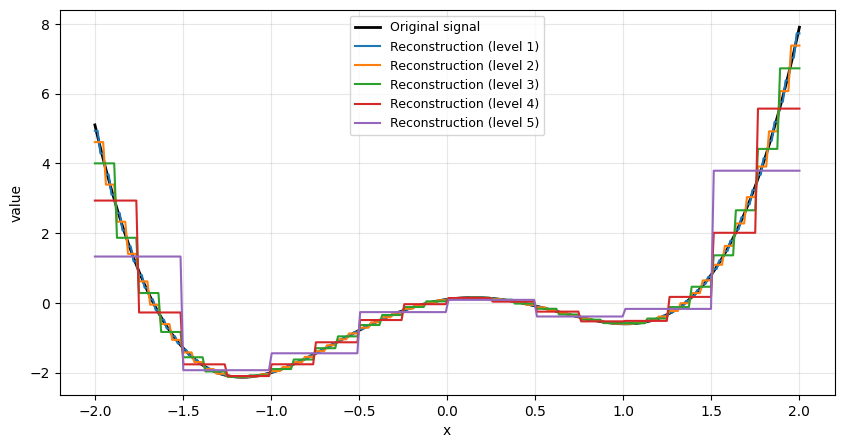

In [32]:
fig, ax = plt.subplots(figsize=(10.0, 5.0))

ax.plot(x_grid, signal, color='k', linewidth=2.0, label='Original signal')

for level in range(1, levels + 1):
    zero_details = [np.zeros_like(detail) for detail in details[:level]]
    approximation_only = reconstruct_from_coeffs(approximations[level], zero_details)
    ax.plot(x_grid, approximation_only, linewidth=1.5, label=f'Reconstruction (level {level})')

# ax.set_title('Original signal and approximation-only reconstructions at all scales')
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.grid(True, alpha=0.3)
ax.legend(frameon=True, fontsize=9)
plt.show()


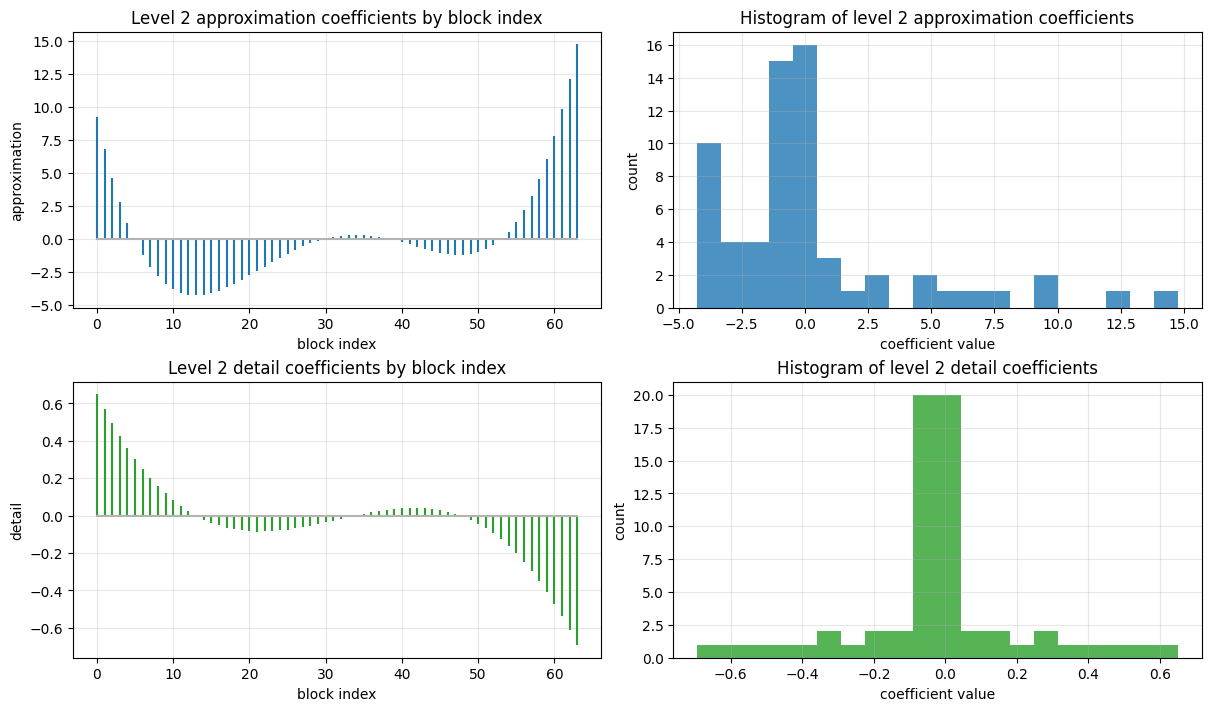

In [33]:
level_2_approximation = approximations[2]
level_2_detail = details[1]

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), constrained_layout=True)

approx_index = np.arange(level_2_approximation.size)
detail_index = np.arange(level_2_detail.size)

axes[0, 0].stem(approx_index, level_2_approximation, linefmt='tab:blue', markerfmt=' ', basefmt='0.7')
axes[0, 0].set_title('Level 2 approximation coefficients by block index')
axes[0, 0].set_xlabel('block index')
axes[0, 0].set_ylabel('approximation')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(level_2_approximation, bins=20, color='tab:blue', alpha=0.8)
axes[0, 1].set_title('Histogram of level 2 approximation coefficients')
axes[0, 1].set_xlabel('coefficient value')
axes[0, 1].set_ylabel('count')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].stem(detail_index, level_2_detail, linefmt='tab:green', markerfmt=' ', basefmt='0.7')
axes[1, 0].set_title('Level 2 detail coefficients by block index')
axes[1, 0].set_xlabel('block index')
axes[1, 0].set_ylabel('detail')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(level_2_detail, bins=20, color='tab:green', alpha=0.8)
axes[1, 1].set_title('Histogram of level 2 detail coefficients')
axes[1, 1].set_xlabel('coefficient value')
axes[1, 1].set_ylabel('count')
axes[1, 1].grid(True, alpha=0.3)

plt.show()


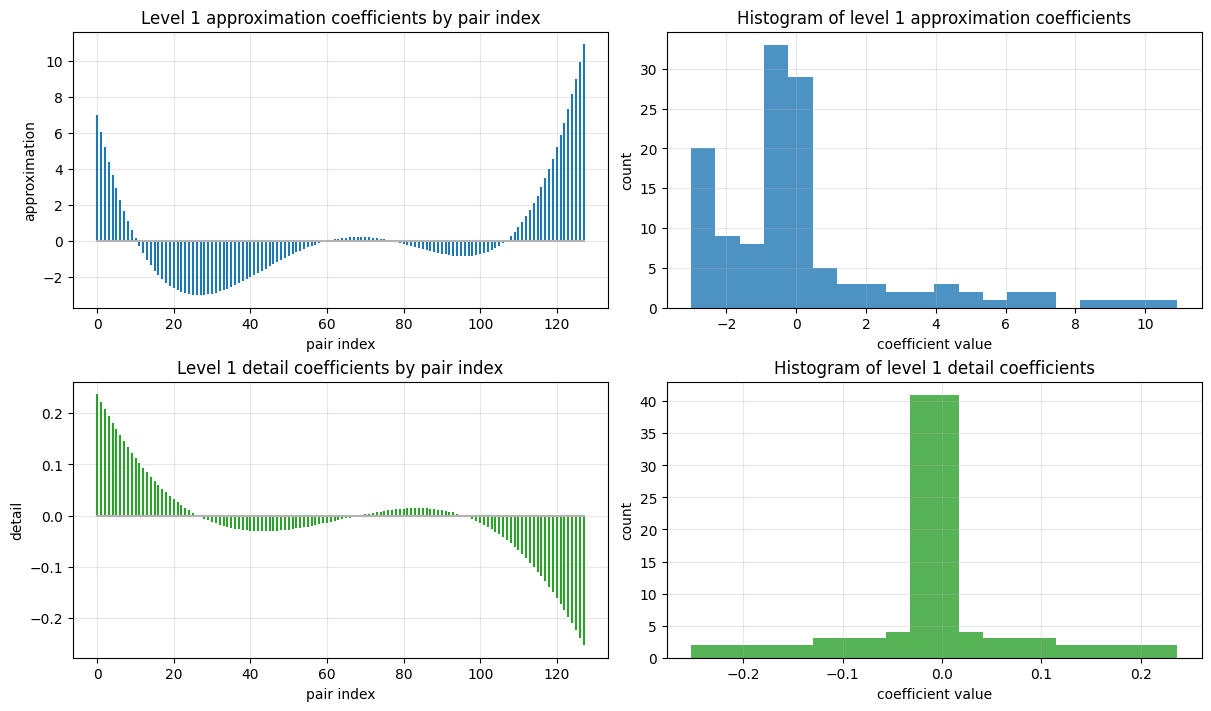

In [34]:
level_1_approximation = approximations[1]
level_1_detail = details[0]

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), constrained_layout=True)

approx_index = np.arange(level_1_approximation.size)
detail_index = np.arange(level_1_detail.size)

axes[0, 0].stem(approx_index, level_1_approximation, linefmt='tab:blue', markerfmt=' ', basefmt='0.7')
axes[0, 0].set_title('Level 1 approximation coefficients by pair index')
axes[0, 0].set_xlabel('pair index')
axes[0, 0].set_ylabel('approximation')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(level_1_approximation, bins=20, color='tab:blue', alpha=0.8)
axes[0, 1].set_title('Histogram of level 1 approximation coefficients')
axes[0, 1].set_xlabel('coefficient value')
axes[0, 1].set_ylabel('count')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].stem(detail_index, level_1_detail, linefmt='tab:green', markerfmt=' ', basefmt='0.7')
axes[1, 0].set_title('Level 1 detail coefficients by pair index')
axes[1, 0].set_xlabel('pair index')
axes[1, 0].set_ylabel('detail')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(level_1_detail, bins=20, color='tab:green', alpha=0.8)
axes[1, 1].set_title('Histogram of level 1 detail coefficients')
axes[1, 1].set_xlabel('coefficient value')
axes[1, 1].set_ylabel('count')
axes[1, 1].grid(True, alpha=0.3)

plt.show()
